In [1]:
%matplotlib inline
import os
import sys
from os.path import join as pjoin
from tifffile import imread, imwrite, TiffFile
import numpy as np
import shutil
import matplotlib.pyplot as plt
from glob import glob
import pandas as pd
import cv2
from tqdm import tqdm
import subprocess
from scipy.ndimage import gaussian_filter,median_filter

project_root = '/home/lsh/WF_GoNogo'
if project_root not in sys.path:
    sys.path.append(project_root)
from utils.wfield_utils import *

In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import cupy as cp
cp._default_memory_pool.free_all_blocks()

### read the single-day data

/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250911/20250911-160206-405Timestamp.csv
Experiments found: ['20250911-160206']
/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250911/process/20250911-160206-wfield
33494 33495


/home/lsh/WF_GoNogo/wf_gonogo/lib/python3.11/site-packages/tifffile/tifffile.py:1750: UserWarning: <tifffile.TiffWriter '20250911-160206-merged.tif'> writing nonconformant BigTIFF ImageJ
  warnings.warn(


Merged file saved: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250911/process/20250911-160206-wfield/20250911-160206-merged.tif


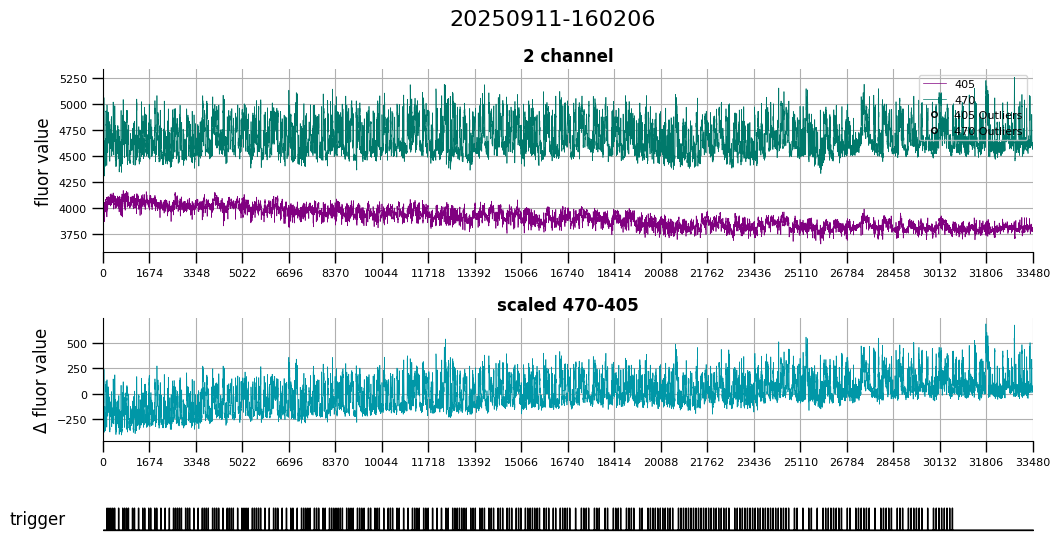

Finished merging for single day.


In [147]:
%matplotlib inline
def filename2int(filename):
    import re
    nums = re.findall(r'\d+', filename)
    return int(nums[-1]) if nums else -1

def organize_tif(folder_path, processPath):
    folder_name = os.path.basename(folder_path)
    tif_path = folder_path + '.tif'
    if os.path.exists(tif_path):
        print(f'importing {tif_path}')
        image_stack = imread(tif_path)
        print(f'finish importing {tif_path}')
    else:
        image_path_ls = glob(os.path.join(folder_path, '*.tif'))
        image_path_ls = sorted(image_path_ls, key=filename2int)
        image_stack = [imread(tiff) for tiff in image_path_ls]
    mean_values = [np.mean(frame) for frame in image_stack]
    output_value = os.path.join(processPath, folder_name + "-Values.csv")
    np.savetxt(output_value, mean_values, delimiter=",")
    return np.array(image_stack)

def merge_two_channels(rawPath, processPath, experiment):
    os.makedirs(os.path.join(processPath, experiment + "-wfield"), exist_ok=True)
    mergePath = os.path.join(processPath, experiment + "-wfield")
    merge_file = os.path.join(mergePath, experiment + "-merged.tif")
    if not os.path.exists(merge_file):
        tif_405 = organize_tif(os.path.join(rawPath, experiment + "-405"), processPath)
        tif_470 = organize_tif(os.path.join(rawPath, experiment + "-470"), processPath)
        print(tif_405.shape[0], tif_470.shape[0])

        if tif_405.shape[0] != tif_470.shape[0]:
            n_frames = min(tif_405.shape[0], tif_470.shape[0])
            tif_405 = tif_405[:n_frames]
            tif_470 = tif_470[:n_frames]
        merged_tif = np.concatenate((tif_470[:, np.newaxis], tif_405[:, np.newaxis]), axis=1)
        imwrite(merge_file, merged_tif, imagej=True, bigtiff=True)
        print(f"Merged file saved: {merge_file}")
    else:
        print(f"Merged {experiment} already exists")

        import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from tifffile import imread

# def plotFluor(path, experiment):
#     merged_file = os.path.join(path, experiment + '-wfield', experiment + '-merged.tif')
#     print("loading file:", merged_file)
#     stack = imread(merged_file)  # shape: (T, 2, H, W)
#     if stack.ndim == 4 and stack.shape[1] == 2:
#         fluor_470 = stack[:, 0, :, :]  # 通道0是470
#         mean_trace = fluor_470.mean(axis=(1, 2))  # 每帧的平均值
        
#         plt.figure(figsize=(8, 4))
#         plt.plot(mean_trace, label='470 mean F')
#         plt.xlabel('Frame')
#         plt.ylabel('Mean Fluorescence')
#         plt.title(f'{experiment}: 470通道平均荧光')
#         plt.legend()
#         plt.tight_layout()
#         plt.show()
#     else:
#         print("Stack format error or missing channels.")


# ========== 主流程 ==========
date = '20250911'
mice = 'A092'
folder_path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu"
single_day_path = pjoin(folder_path,mice,date)
rawPath = single_day_path
processPath = os.path.join(single_day_path, "process")

items = glob(os.path.join(rawPath, '202?????-??????-4*'))
print(items[0])
experiments = list(set([os.path.basename(item)[:15] for item in items]))
print("Experiments found:", experiments)

for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")
    print(mergePath)
    merge_two_channels(rawPath, processPath, experiment)
    plotFluor(single_day_path, experiment)
    
print("Finished merging for single day.")

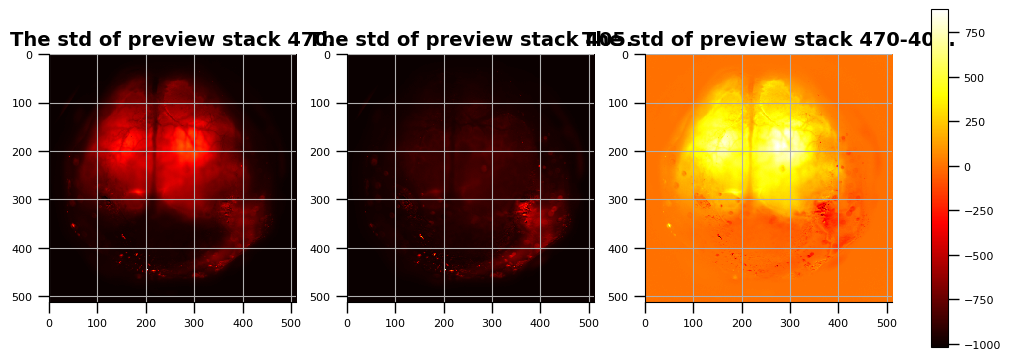

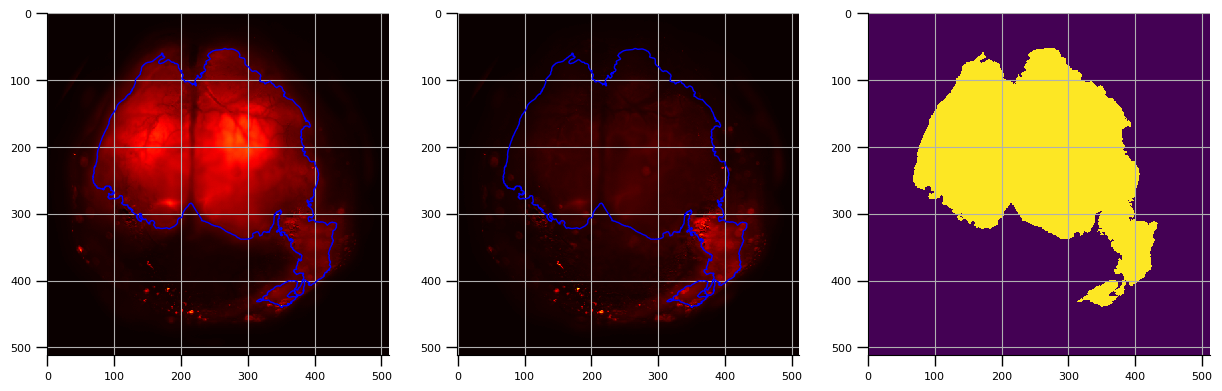

In [154]:
def show_images(images, titles=None, cmap='hot', colorbar=True):
    """
    Display a list of images side by side with a shared colorbar.

    Parameters:
    - images: list of 2D numpy arrays (images to display)
    - titles: list of strings (titles for each image)
    - cmap: string (colormap to use)
    - colorbar: bool (whether to display shared colorbar)
    """
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(10, 4.5), constrained_layout=True)

    # 保证 axes 是可迭代的
    if n == 1:
        axes = [axes]

    # 显示图像并收集每个im对象
    im_objs = []
    for i in range(n):
        im = axes[i].imshow(images[i], cmap=cmap, aspect='equal')
        im_objs.append(im)
        if titles:
            axes[i].set_title(titles[i])
        axes[i].axis('on')  # 不显示坐标轴
        axes[i].grid()

    # 添加共享 colorbar（以最后一个im对象为准）
    if colorbar:
        fig.colorbar(im_objs[-1], ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

    plt.show()

for experiment in experiments:    

    plot_test = True

    n_preview = 600
    tiff_list_470 = glob(pjoin(single_day_path, experiment + '*-470/*.tif'))[:n_preview]
    preview_stack_470 = np.array([imread(tiff) for tiff in tiff_list_470])
    tiff_list_405 = glob(pjoin(single_day_path, experiment + '*-405/*.tif'))[:n_preview]
    preview_stack_405 = np.array([imread(tiff) for tiff in tiff_list_405])
    preview_std_470 = np.std(preview_stack_470, axis=0)
    preview_std_405 = np.std(preview_stack_405, axis=0)

    if plot_test:
        images = [preview_std_470, preview_std_405, preview_std_470 - preview_std_405]
        title = ['The std of preview stack 470.', 
                'The std of preview stack 405.', 
                'The std of preview stack 470-405.']
        show_images(images, titles=title, colorbar=True)
        std_level = 250

    contour = measure.find_contours(image=preview_std_470, level=std_level)
    contour_len = [len(_contour) for _contour in contour]
    contour_max = contour[np.argmax(contour_len)]

    mask = np.zeros_like(preview_std_470)
    mask_edge = np.flip(contour_max, axis=1).astype(int)
    mask = cv2.fillPoly(mask, [mask_edge], 1)
    mergePath = os.path.join(processPath, experiment + "-wfield")
    save_path = os.path.join(mergePath, "mask.npy")
    np.save(save_path, mask)


    if plot_test:
        fig, axis = plt.subplots(figsize=(15, 5), nrows=1, ncols=3)
        
        axis[0].imshow(preview_std_470, cmap='hot')
        axis[0].plot(contour_max[:, 1], contour_max[:, 0], linewidth=1, color='blue')
        axis[0].grid()
        axis[1].imshow(preview_std_405, cmap='hot')
        axis[1].plot(contour_max[:, 1], contour_max[:, 0], linewidth=1, color='blue')
        axis[1].grid()
        axis[2].imshow(mask)
        axis[2].grid()
        plt.show()

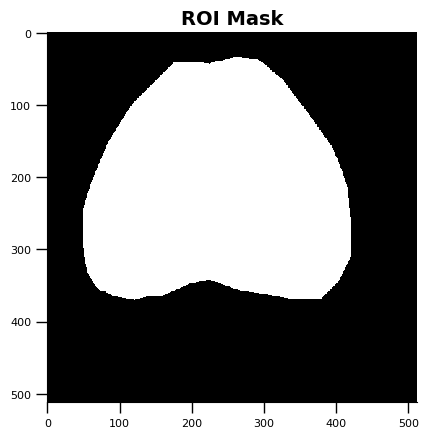

In [156]:
import numpy as np
from roifile import ImagejRoi
from matplotlib.path import Path
import matplotlib.pyplot as plt


roi_path = os.path.join(mergePath, 'mask.roi')  
roi = ImagejRoi.fromfile(roi_path)
coords = roi.coordinates() 


H, W = 512, 512
y, x = np.mgrid[:H, :W]
points = np.stack((x.flatten(), y.flatten()), axis=-1)


roi_path = Path(coords)
mask = roi_path.contains_points(points).reshape(H, W)


plt.imshow(mask, cmap='gray')
plt.title("ROI Mask")
plt.show()

# save as .npy
np.save(os.path.join(mergePath,'mask.npy'), mask)

In [157]:
import os
import numpy as np
from tifffile import imread
from os.path import join as pjoin
from tqdm import tqdm

chunk_size = 256  # 每次处理的帧数块大小

for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")  
    print(f"Processing folder: {mergePath}")

    # 找到 tiff 文件
    tif_files = [f for f in os.listdir(mergePath) if f.endswith('-merged.tif')]
    if len(tif_files) != 1:
        print('!!! There should be exactly one merged tiff file in the folder.')
        continue
    tif_path = pjoin(mergePath, tif_files[0])

    # 读取 mask
    mask_path = os.path.join(mergePath, "mask.npy")
    mask = np.load(mask_path).astype(np.uint16)  # shape (H, W)

    # 使用 imread 读取整个 tiff 栈
    tif_stack = imread(tif_path).astype(np.uint16)  # shape (n_frames, n_channels, H, W)
    n_frames, n_channels, H, W = tif_stack.shape
    print(f"Tiff shape: {n_frames} frames, {n_channels} channels, {H}x{W}")

    # 输出 bin 文件路径
    bin_path = pjoin(mergePath, f"{n_frames}_{n_channels}_{H}_{W}_masked_uint16.bin")
    os.makedirs(os.path.dirname(bin_path), exist_ok=True)

    # 分块处理并写入二进制
    with open(bin_path, "wb") as fout:
        for start in tqdm(range(0, n_frames, chunk_size), desc="Processing chunks"):
            end = min(start + chunk_size, n_frames)
            block = tif_stack[start:end]  # shape (chunk, n_channels, H, W)
            block = block * mask[None, None, :, :]  # 广播 mask
            block.astype(np.uint16).tofile(fout)

    print('Binary file saved:', bin_path)

print('Finished generating all binary files.')

Processing folder: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250911/process/20250911-160206-wfield
Tiff shape: 33494 frames, 2 channels, 512x512


Processing chunks: 100%|██████████| 131/131 [00:56<00:00,  2.33it/s]

Binary file saved: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250911/process/20250911-160206-wfield/33494_2_512_512_masked_uint16.bin
Finished generating all binary files.





Path: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250911
experiment: 20250911-160206
bin_path: /home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250911/process/20250911-160206-wfield/33494_2_512_512_masked_uint16.bin


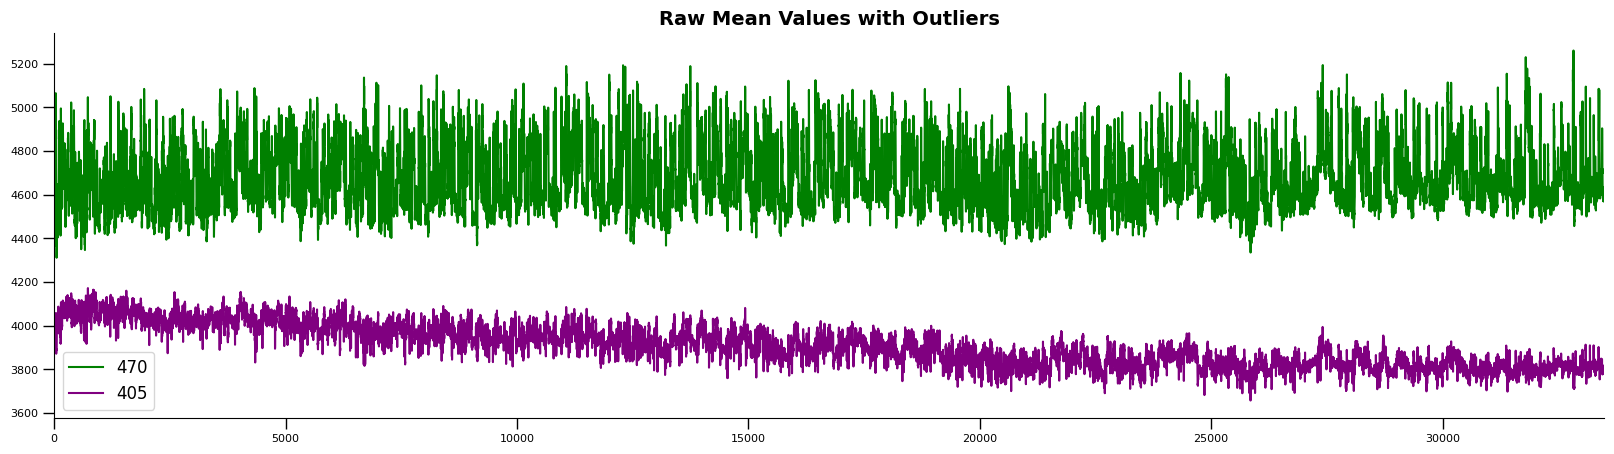

No outliers detected


In [158]:
# detect outliers based on the mean values of 405 and 470 channels,
# and correct the outliers by averaging the values of the previous and next frames

overwrite = True
# for path in path_all:
path = single_day_path
stim_name = os.path.split(path)[-1]
    # rawPath = pjoin(path, "raw")
processPath = pjoin(path, "process")
    
items = glob(pjoin(path, '202?????-??????-4*'))
experiments = list(set([os.path.basename(item)[:15] for item in items]))

for experiment in experiments:
    print("\n\n\nPath: "+ path)
    print("experiment:", experiment)
    bin_path = glob(pjoin(processPath, experiment+"-wfield", '*uint16.bin'))[0]
    print(f'bin_path: {bin_path}')
    
    values_405_path = pjoin(path, "process", f'{experiment}-405-Values.csv')
    values_470_path = pjoin(path, "process", f'{experiment}-470-Values.csv')
    mean_values_405 = np.loadtxt(values_405_path, delimiter=',')
    mean_values_470 = np.loadtxt(values_470_path, delimiter=',')
    n_frames = min(mean_values_405.shape[0], mean_values_470.shape[0])
    mean_values_405 = mean_values_405[:n_frames]
    mean_values_470 = mean_values_470[:n_frames]
    mean_values = np.concatenate((np.expand_dims(mean_values_470, axis=1), np.expand_dims(mean_values_405, axis=1)), axis=1)
    
    outlier_index_470, outlier_index_405 = detect_outlier(mean_values, std_thr=10, plot=True)
    if len(outlier_index_470) > 0 or len(outlier_index_405) > 0:
        mean_values_corrected = correct_lum_outlier(bin_path, outlier_index_470, outlier_index_405, plot=True, overwrite=overwrite)
        np.savetxt(pjoin(path, "process", f'{experiment}-corrected values.csv'), mean_values_corrected, delimiter=",")





In [8]:
def detect_lum_outlier(mean_values, lum_thr_coef=0.3, plot=True):
    '''
    Detect outliers in the mean_values array.
    Parameters:
        mean_values: numpy array, the mean values of the image stack. 
        The first column is the mean values of 470 channel, the second column is the mean values of 405 channel.
        lum_thr_coef: luminance threshold coefficient for detecting luminance outliers.
    Returns:
        outlier_index: numpy array, the index of the outliers, 
        each row contains the start and end index of the outliers,
        the value of mean_values[start:end] is considered as outliers.
    '''
    # detecting luminance outliers
    outlier_lum_470 = mean_values[:, 0] < np.mean(mean_values[:, 0])*lum_thr_coef
    outlier_lum_idx_470 = np.where(outlier_lum_470)[0]
    if len(outlier_lum_idx_470) > 0:
        # Frames before and after the detected outliers are also considered as outliers,
        # Output index is the start and end index of the outliers,
        # Note the frame of the end index is normal, so add 2 to the end index.
        outlier_lum_idx_470 = np.array((outlier_lum_idx_470[0]-1, outlier_lum_idx_470[-1]+2))

    outlier_lum_405 = mean_values[:, 1] < np.mean(mean_values[:, 1])*lum_thr_coef
    outlier_lum_idx_405 = np.where(outlier_lum_405)[0]
    if len(outlier_lum_idx_405) > 0:
        outlier_lum_idx_405 = np.array((outlier_lum_idx_405[0]-1, outlier_lum_idx_405[-1]+2))

    outlier_index = [outlier_lum_idx_470, outlier_lum_idx_405]

    if plot:
        fig, ax = plt.subplots(figsize=(20, 5))
        ax.plot(mean_values[:, 0], label='470', color='g')
        ax.plot(mean_values[:, 1], label='405', color='purple')
        ax.set_xlim(0, len(mean_values))
        # for idx in outlier_index[0]:
        #     ax.axvline(x=idx, color='r', linestyle='--')
        # for idx in outlier_index[1]:
        #     ax.axvline(x=idx, color='r', linestyle='--')
        if len(outlier_lum_idx_470) > 0:
            ax.hlines(np.mean(mean_values[:, 0])*lum_thr_coef, 0, len(mean_values), color='g', linestyle='--')
        if len(outlier_lum_idx_405) > 0:
            ax.hlines(np.mean(mean_values[:, 1])*lum_thr_coef, 0, len(mean_values), color='purple', linestyle='--')
        ax.legend()
        plt.title('raw mean values')
        plt.show()
    
    if len(outlier_lum_idx_470) > 0 or len(outlier_lum_idx_405) > 0:
        print('\33[91mluminance outliers detected!\33[0m')
        print('luminance outlier index:\n')
        print(outlier_index)
    else:
        print('No luminance outliers detected')

    return outlier_index



def correct_lum_outlier(bin_path, outlier_index_470, outlier_index_405, overwrite=True, plot=True):
    '''
    Correct the luminance outliers frames in the merged tiff file.
    '''
    if (outlier_index_470 is not None) or (outlier_index_405 is not None):
        print('luminance outliers frames need to be corrected!')
        bin_name = os.path.splitext(os.path.basename(bin_path))[0]
        dtype = bin_name.split('_')[-1]
        # shape = tuple([int(i) for i in bin_name.split('_')[:-1]])
        shape = tuple([int(i) for i in bin_name.split('_')[:-1] if i.isdigit()])

        images = np.memmap(bin_path, dtype=dtype, mode='r+', shape=shape)
        if outlier_index_470 is not None:
            for i_outlier in outlier_index_470:
                start, end = i_outlier
                images[start:end+1, 0, :, :] = 0.5*images[start-1, 0, :, :] + 0.5*images[end+1, 0, :, :]
        if outlier_index_405 is not None:
            for i_outlier in outlier_index_405:
                start, end = i_outlier
                images[start:end+1, 1, :, :] = 0.5*images[start-1, 1, :, :] + 0.5*images[end+1, 1, :, :]
        if overwrite:
            images.flush()
            print('Luminance outliers frames corrected!')
       
    else:
        print('No luminance outliers frames to correct')


    mean_values_470 = images[:, 0, :, :].mean(axis=(1,2))
    mean_values_405 = images[:, 1, :, :].mean(axis=(1,2))
    mean_values_corrected = np.concatenate((mean_values_470[:, np.newaxis], mean_values_405[:, np.newaxis]), axis=1)    
    if plot:
        fig, ax = plt.subplots(figsize=(20, 5))
        ax.plot(mean_values_470, label='470', color='g')
        ax.plot(mean_values_405, label='405', color='purple')
        ax.set_xlim(0, len(mean_values_470))
        ax.legend()
        plt.title('correct_luminance_outlier')
        plt.show()

    return mean_values_corrected



def detect_cross_outlier(time_stamp_470, time_stamp_405, time_thr=10):
    '''
    detect the cross-channel outliers based on the time stamps of 405 and 470 channels
    cross-channel: the 405 or 470 channel frames wrongly recoreded.
    time_thr: the threshold of the vairance of the interval between the 405 and 470 channels
    '''
    diff_time = abs(time_stamp_470 - time_stamp_405)
    time_outliers_idx_advance = np.where(diff_time < (50-time_thr))[0]
    time_outliers_idx_lag = np.where(diff_time > (50+time_thr))[0] + 1

    if time_stamp_470[0] < time_stamp_405[0]: # 470 channel starts first
        return time_outliers_idx_lag, time_outliers_idx_advance
    else: # 405 channel starts first
        return time_outliers_idx_advance, time_outliers_idx_lag



def correct_cross_outlier(bin_path, outlier_index_470, outlier_index_405, overwrite=True, plot=True):
    '''
    Correct the outliers frames in the merged tiff file.
    Parameters:
        bin_path: string, the path of the bin file.
        outlier_index_405: numpy array, the index of the outliers in 405 channel.
        outlier_index_470: numpy array, the index of the outliers in 470 channel.
    '''

    if (len(outlier_index_470) > 0) or (len(outlier_index_405) > 0):
        print('cross-channel outliers frames need to be corrected!')
        bin_name = os.path.splitext(os.path.basename(bin_path))[0]
        dtype = bin_name.split('_')[-1]
        # shape = tuple([int(i) for i in bin_name.split('_')[:-1]])
        shape = tuple([int(i) for i in bin_name.split('_')[:-1] if i.isdigit()])

        images = np.memmap(bin_path, dtype=dtype, mode='r+', shape=shape)
        if len(outlier_index_470) > 0:
            for i in outlier_index_470:
                print(f'correct 470channel {i}th frame')
                images[i, 0, :, :] = 0.5*images[i-1, 0, :, :] + 0.5*images[i+1, 0, :, :]
        if len(outlier_index_405) > 0:
            for i in outlier_index_405:
                print(f'correct 405channel {i}th frame')
                images[i, 0, :, :] = 0.5*images[i-1, 0, :, :] + 0.5*images[i+1, 0, :, :] # in this case, 470 channel also need to be corrected
                # images[i, 0, :, :] = 0
                images[i, 1, :, :] = 0.5*images[i-1, 1, :, :] + 0.5*images[i+1, 1, :, :]
        if overwrite:
            images.flush() # save the changes
            print('cross-channel outliers frames corrected!')

    else:
        print('No cross-channel outliers frames to correct')

    
    mean_values_470 = images[:, 0, :, :].mean(axis=(1,2))
    mean_values_405 = images[:, 1, :, :].mean(axis=(1,2))
    mean_values_corrected = np.concatenate((mean_values_470[:, np.newaxis], mean_values_405[:, np.newaxis]), axis=1)
    if plot:
        fig, ax = plt.subplots(figsize=(20, 5))
        ax.plot(mean_values_470, label='470', color='g')
        ax.plot(mean_values_405, label='405', color='purple')
        ax.set_xlim(0, len(mean_values_470))
        ax.legend()
        plt.title('correct_cross-channel_outlier')
        plt.show()


    return mean_values_corrected



#########################################################################################################################
def detect_outlier(mean_values, std_thr=5, plot=True):
    '''
    Detect outliers in the mean_values array.
    Parameters:
        mean_values: numpy array, the mean values of the image stack. 
        The first column is the mean values of 470 channel, the second column is the mean values of 405 channel.
        std_thr: luminance threshold coefficient for detecting luminance outliers.
    Returns:
        outlier_index: list, where each element is a tuple representing a segment of outlier indices.
        Each tuple contains the start and end index of a continuous outlier segment.
    '''
    def find_continuous_outliers(outlier_lum_idx):
        """
        Helper function to find continuous segments of outliers.
        If the segment length is greater than 3, adjust start and end positions.
        """
        if len(outlier_lum_idx) == 0:
            return []

        segments = []
        start = outlier_lum_idx[0]
        
        # Iterate through outlier indices and group continuous outliers
        for i in range(1, len(outlier_lum_idx)):
            if outlier_lum_idx[i] != outlier_lum_idx[i-1] + 1:
                segments.append((start, outlier_lum_idx[i-1]))  # End the previous segment
                start = outlier_lum_idx[i]  # Start a new segment

        # Append the last segment
        segments.append((start, outlier_lum_idx[-1]))

        # Adjust the start and end positions for segments with length > 3
        adjusted_segments = []
        for segment in segments:
            start, end = segment
            if end - start + 1 > 3:  # If the segment length is greater than 3
                # Adjust start and end positions
                adjusted_start = max(start - 1, 0)  # Prevent going below 0
                adjusted_end = min(end + 1, len(mean_values) - 1)  # Prevent going above the length of the data
                adjusted_segments.append((adjusted_start, adjusted_end))
            else:
                adjusted_segments.append(segment)

        return adjusted_segments
    
    # Detecting outliers for 470 channel
    outlier_lum_470 = mean_values[:, 0] < mean_values[:, 0].mean() - std_thr * mean_values[:, 0].std()
    outlier_lum_idx_470 = np.where(outlier_lum_470)[0]
    outlier_lum_idx_470_segments = find_continuous_outliers(outlier_lum_idx_470)

    # Detecting outliers for 405 channel
    outlier_lum_405 = (mean_values[:, 1] < mean_values[:, 1].mean() - std_thr * mean_values[:, 1].std()) | (
        mean_values[:, 1] > mean_values[:, 1].mean() + std_thr * mean_values[:, 1].std())
    outlier_lum_idx_405 = np.where(outlier_lum_405)[0]
    outlier_lum_idx_405_segments = find_continuous_outliers(outlier_lum_idx_405)

    # Combine both segments
    outlier_index = [outlier_lum_idx_470_segments, outlier_lum_idx_405_segments]

    # Plot if requested
    if plot:
        fig, ax = plt.subplots(figsize=(20, 5))
        ax.plot(mean_values[:, 0], label='470', color='g')
        ax.plot(mean_values[:, 1], label='405', color='purple')
        ax.set_xlim(0, len(mean_values))

        # Plot outlier points and annotate them
        for segment in outlier_lum_idx_470_segments:
            start, end = segment
            ax.plot(np.arange(start, end+1), mean_values[start:end+1, 0], 'ko', fillstyle='none', markerfacecolor='none')
            ax.annotate(f'{start+1:.0f}', (start, mean_values[start, 0]), textcoords="offset points", xytext=(0, 10), ha='center')

        for segment in outlier_lum_idx_405_segments:
            start, end = segment
            ax.plot(np.arange(start, end+1), mean_values[start:end+1, 1], 'ro', fillstyle='none', markerfacecolor='none')
            ax.annotate(f'{start+1:.0f}', (start, mean_values[start, 1]), textcoords="offset points", xytext=(0, 10), ha='center')

        ax.legend()
        plt.title('Raw Mean Values with Outliers')
        plt.show()
    
    if len(outlier_lum_idx_470_segments) > 0 or len(outlier_lum_idx_405_segments) > 0:
        print('\33[91moutliers detected!\33[0m')
        print('Outlier index:\n')
        print(outlier_index)
    else:
        print('No outliers detected')

    return outlier_index



### SVT_filtered

['/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250911/process/20250911-160206-wfield/33494_2_512_512_masked_uint16.bin']


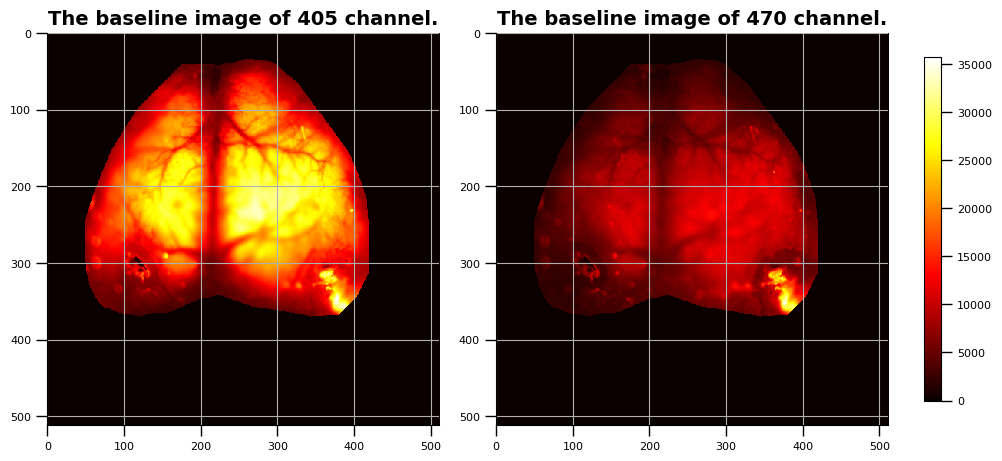

Computing SVT from the raw data: 100%|██████████| 67/67 [00:56<00:00,  1.19it/s]


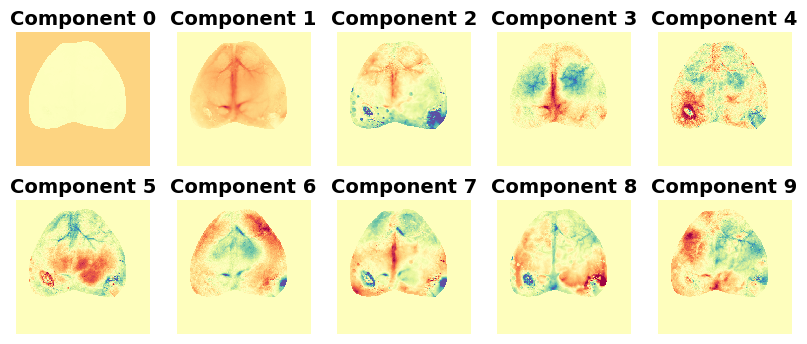

Skipping lowpass on the violet channel.
Done hemodynamic correction in 19.54736876487732 s 


In [160]:
for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")    
    print(glob(pjoin(mergePath, '*uint16.bin')))
    dat = mmap_dat(glob(pjoin(mergePath, '*uint16.bin'))[0])
    image_base_min = np.min(dat[-300:, :, :, :], axis=0)
    np.save(pjoin(mergePath, 'frames_average.npy'), image_base_min)

    if plot_test:
        images = [image_base_min[0], image_base_min[1]]
        title = ['The baseline image of 405 channel.', 'The baseline image of 470 channel.']
        show_images(images, titles=title, colorbar=True)
    
    U, SVT = approximate_svd(dat, image_base_min)

    np.save(pjoin(mergePath,'U.npy'), U)
    np.save(pjoin(mergePath,'SVT.npy'), SVT)

    if plot_test:
        ncomponents = 10
        ncols = 5
        nrows = int(np.ceil(ncomponents/ncols))
        fig = plt.figure(figsize=[2*ncols, 2*nrows])
        for icomponent in range(ncomponents):
            fig.add_subplot(nrows, ncols, icomponent+1)
            plt.imshow(U[:, :, icomponent], clim=[-0.01,0.01],cmap='Spectral_r')
            plt.title('Component {}'.format(icomponent))
            plt.axis('off')
        plt.show()
        
    tstart = time.time()
    fs = 10
    freq_highpass = 0.001
    SVT_470 = SVT[:,0::2]
    t = np.arange(SVT.shape[1]) # interpolate the violet
    from scipy.interpolate import interp1d
    SVT_405 = interp1d(t[1::2], SVT[:,1::2], axis=1,
                        fill_value='extrapolate')(t[0::2])
    SVTcorr, rcoeffs, T = hemodynamic_correction(U, 
                                                 SVT_470, 
                                                 SVT_405, 
                                                 fs=fs,
                                                 freq_highpass=freq_highpass,
                                                 freq_lowpass=10)  

    print('Done hemodynamic correction in {0} s '.format(time.time()-tstart))
    # SVTcorr = SVT_470 - SVT_405

    # np.save(pjoin(path,'rcoeffs.npy'), rcoeffs)
    # np.save(pjoin(path,'T.npy'),T)
    np.save(pjoin(mergePath,'SVTcorr.npy'), SVTcorr)

    from scipy.signal import detrend, butter, filtfilt

    # 参数
    fs = 10  # 帧率 Hz
    highpass = 0.01  # Hz

    # 线性去趋势
    SVT_detrended = detrend(SVTcorr, axis=1)

    # 高通滤波
    b, a = butter(2, highpass/(fs/2), btype='high')
    SVT_filtered = filtfilt(b, a, SVT_detrended, axis=1)


In [161]:
SVT_filtered.shape

(200, 33494)

### Trigger


[ 6.842  6.803  6.827  6.593 14.547 14.693  6.841  6.912  6.882 14.77
  6.887 14.834 15.049  6.993 14.55   6.986 14.809  7.008 15.026 15.143
 15.288 15.075  7.061  7.112  7.097  7.074 15.195  7.181  7.085 15.356
 15.293 15.184  7.17   7.163  7.249 15.38   7.325  7.312  7.256 15.38
 15.402  7.365  7.353  7.3   15.521 15.571  7.357  7.376  7.372 15.408
  7.349  7.412  7.525  7.469 15.562 15.629 15.522  7.501  7.544 15.622
 15.666 15.641  7.584 15.557 15.554  7.659  7.643  7.615  7.685 15.806
  7.647  7.671 15.591  7.693 15.645  7.752  7.782  7.788  7.684  7.702
  7.704 15.321  7.784  7.81   7.722 15.807  7.807  7.824  7.826 15.91
  7.767 15.692  7.884  7.877 15.988 15.929  7.862  7.943 15.837  7.949
 15.963 15.934 16.104  8.019  8.013  8.042 16.003  8.053  8.078 16.096
 16.117 15.988 16.004  8.108 16.079  8.191  8.075  8.185  8.2    8.109
  8.186 16.24   8.194  8.251 16.235  8.264  8.221 16.28   8.292  8.264
 16.294  8.315  8.29  15.951  8.348  8.317 16.336  8.354  8.351 16.358
  8.473  

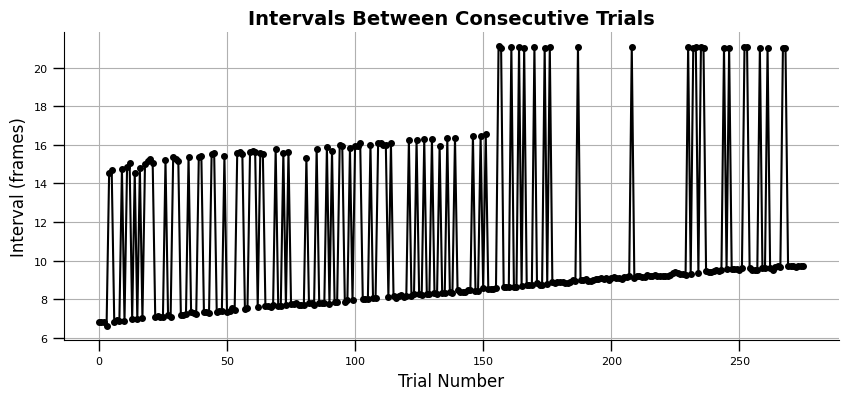

277
Generated trial_onsets.npy for 20250911-160206


In [162]:
stimfile_path = pjoin(single_day_path, experiment + ".csv")
def generate_trial_onsets(stimfile_path):
    if not os.path.exists(stimfile_path):
        print(f"{experiment} without stim-file, skip")
        return
    

    stimfile = np.loadtxt(stimfile_path, delimiter=',')
    stim_signal = stimfile[:, 0] 
    onset_indices = (np.where(np.diff(stim_signal) == 1)[0] + 1)/1000


    start_intervals = np.diff(onset_indices)
    print(start_intervals)
    plt.figure(figsize=(10, 4))
    plt.plot(start_intervals, marker='o')
    plt.xlabel('Trial Number')
    plt.ylabel('Interval (frames)')
    plt.title('Intervals Between Consecutive Trials')
    plt.grid(True)
    plt.show()
    
    print((len(onset_indices)))
    # trial_onsets = np.stack((np.arange(len(onset_indices)), onset_indices), axis=1)
    trial_onsets = onset_indices

  
    np.save(pjoin(processPath, 'trial_onsets.npy'), trial_onsets)
    print(f"Generated trial_onsets.npy for {experiment}")

    return start_intervals

start_intervals = generate_trial_onsets(stimfile_path)

In [163]:
matfile_path = glob(pjoin(single_day_path,"*.mat"))
print(matfile_path)


import scipy.io as sio

mat_data = sio.loadmat(matfile_path[0], squeeze_me=True, struct_as_record=False)


session = mat_data['SessionData']

trial_start_byBpod = session.TrialStartTimestamp
trial_end_byBpod = session.TrialEndTimestamp

print("TrialStartTimestamp shape:", trial_start_byBpod.shape)
print("TrialEndTimestamp shape:", trial_end_byBpod.shape)
trial_interval_byBpod = trial_end_byBpod - trial_start_byBpod
start_intervals_byBpod = np.diff(trial_start_byBpod)
print(start_intervals_byBpod)

['/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250911/A092_20250911_160438_Data_.mat']
TrialStartTimestamp shape: (277,)
TrialEndTimestamp shape: (277,)
[ 6.8422  6.8031  6.828   6.5932 14.5469 14.6935  6.8415  6.9114  6.8826
 14.7701  6.8878 14.834  15.0498  6.9931 14.5503  6.9857 14.81    7.0085
 15.0264 15.1427 15.289  15.0748  7.0611  7.1126  7.0971  7.0745 15.1955
  7.1809  7.085  15.3565 15.2933 15.1841  7.1704  7.1633  7.2489 15.3804
  7.3256  7.3119  7.2569 15.3804 15.4019  7.3656  7.3534  7.3002 15.5207
 15.5714  7.3571  7.3764  7.3728 15.408   7.3493  7.4123  7.5246  7.4697
 15.5622 15.6293 15.5223  7.5014  7.5446 15.6222 15.6666 15.6413  7.5838
 15.5575 15.5547  7.6596  7.6432  7.6145  7.6856 15.806   7.6476  7.671
 15.5914  7.6935 15.6452  7.7521  7.7821  7.7885  7.6847  7.7018  7.7047
 15.3206  7.7846  7.8101  7.7219 15.808   7.807   7.8245  7.8262 15.9102
  7.7674 15.6923  7.8845  7.8766 15.9888 15.9295  7.8623  7.9425 15.8381
  7.9492 15.9631 15.9348 16.

In [164]:
txt_path = glob(pjoin(single_day_path, '*.txt'))
trial_type = None
with open(txt_path[0]) as f:
    for line in f:
        if line.startswith("Data:"):
           
            values = line.split(":", 1)[1].strip()
            values = values.strip("[]")  
            trial_type = [int(x) for x in values.split()]

print(len(trial_type))
print(trial_type[:20]) 


277
[1, 1, 1, 1, 3, 3, 1, 1, 1, 3, 1, 3, 3, 1, 3, 1, 3, 1, 3, 3]


[ 2.00000000e-04  1.00000000e-04  1.00000000e-03  2.00000000e-04
 -1.00000000e-04  5.00000000e-04  5.00000000e-04 -6.00000000e-04
  6.00000000e-04  1.00000000e-04  8.00000000e-04  0.00000000e+00
  8.00000000e-04  1.00000000e-04  3.00000000e-04 -3.00000000e-04
  1.00000000e-03  5.00000000e-04  4.00000000e-04 -3.00000000e-04
  1.00000000e-03 -2.00000000e-04  1.00000000e-04  6.00000000e-04
  1.00000000e-04  5.00000000e-04  5.00000000e-04 -1.00000000e-04
  5.68434189e-14  5.00000000e-04  3.00000000e-04  1.00000000e-04
  4.00000000e-04  3.00000000e-04 -1.00000000e-04  4.00000000e-04
  6.00000000e-04 -1.00000000e-04  9.00000000e-04  4.00000000e-04
 -1.00000000e-04  6.00000000e-04  4.00000000e-04  2.00000000e-04
 -3.00000000e-04  4.00000000e-04  1.00000000e-04  4.00000000e-04
  8.00000000e-04  0.00000000e+00  3.00000000e-04  3.00000000e-04
 -4.00000000e-04  7.00000000e-04  2.00000000e-04  3.00000000e-04
  3.00000000e-04  4.00000000e-04  6.00000000e-04  2.00000000e-04
  6.00000000e-04  3.00000

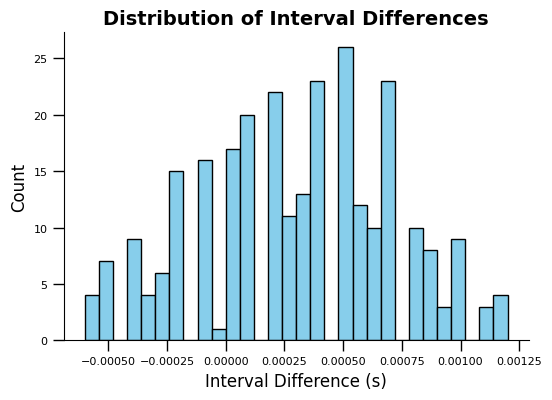

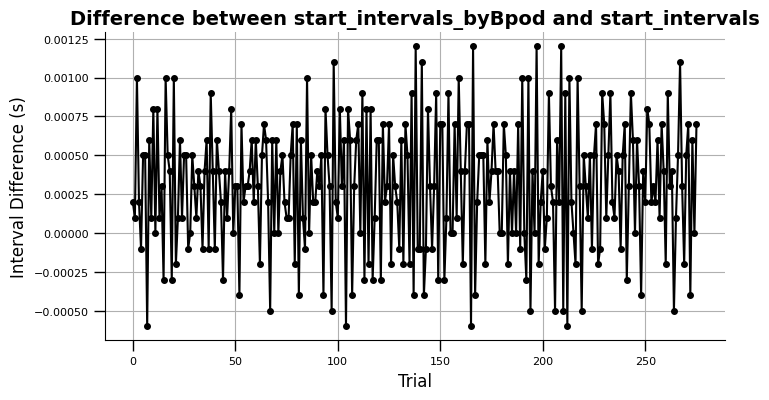

In [165]:
diff = start_intervals_byBpod-start_intervals
print(diff)
print(len(diff))
print(np.std(diff))
print(np.mean(diff))

plt.figure(figsize=(6,4))
plt.hist(diff, bins=30, color='skyblue', edgecolor='k')
plt.xlabel('Interval Difference (s)')
plt.ylabel('Count')
plt.title('Distribution of Interval Differences')
plt.show()


plt.figure(figsize=(8,4))
plt.plot(diff, marker='o', linestyle='-')
plt.xlabel('Trial')
plt.ylabel('Interval Difference (s)')  
plt.title('Difference between start_intervals_byBpod and start_intervals')
plt.grid(True)
plt.show()

In [166]:
trial_onset = np.load(pjoin(processPath, 'trial_onsets.npy'))
trial_end = trial_onset + trial_interval_byBpod
print(trial_end)

[  18.0332   24.8453   31.6483   38.4753   49.5682   64.1152   74.3083
   81.1493   88.0613   99.4435  109.7133  121.1002  135.9342  146.4833
  157.9762  168.0263  179.5122  189.8213  201.3292  216.3552  231.4982
  246.7862  257.3613  264.4223  271.5343  278.6313  290.2052  300.9002
  308.0813  319.6662  335.0222  350.3152  360.9993  368.1693  375.3323
  387.0812  397.9615  405.2863  412.5983  424.3542  439.7342  450.6363
  458.0013  465.3543  477.1542  492.6752  503.7463  511.1033  518.4793
  530.3512  541.2593  548.6083  556.0203  563.5453  575.5142  591.0762
  606.7052  617.7273  625.2283  637.2722  652.8942  668.5602  679.7013
  691.7852  707.3422  718.3962  726.0553  733.6983  741.3132  753.4982
  764.8043  772.4512  784.6222  795.7133  807.9062  819.0512  826.8032
  834.5852  842.3733  850.0573  857.7592  869.9632  880.7843  888.5682
  896.3783  908.6002  919.9073  927.7143  935.5382  947.8642  959.2743
  971.5412  982.7332  990.6173 1002.9942 1018.9826 1030.4113 1038.2733
 1050.

In [167]:
trial_timestamp = np.column_stack((trial_onset, trial_end)) #[trial_start, trial_end]*n_trial

In [168]:
print(trial_timestamp)

[[  12.753    18.0332]
 [  19.595    24.8453]
 [  26.398    31.6483]
 [  33.225    38.4753]
 [  39.818    49.5682]
 [  54.365    64.1152]
 [  69.058    74.3083]
 [  75.899    81.1493]
 [  82.811    88.0613]
 [  89.693    99.4435]
 [ 104.463   109.7133]
 [ 111.35    121.1002]
 [ 126.184   135.9342]
 [ 141.233   146.4833]
 [ 148.226   157.9762]
 [ 162.776   168.0263]
 [ 169.762   179.5122]
 [ 184.571   189.8213]
 [ 191.579   201.3292]
 [ 206.605   216.3552]
 [ 221.748   231.4982]
 [ 237.036   246.7862]
 [ 252.111   257.3613]
 [ 259.172   264.4223]
 [ 266.284   271.5343]
 [ 273.381   278.6313]
 [ 280.455   290.2052]
 [ 295.65    300.9002]
 [ 302.831   308.0813]
 [ 309.916   319.6662]
 [ 325.272   335.0222]
 [ 340.565   350.3152]
 [ 355.749   360.9993]
 [ 362.919   368.1693]
 [ 370.082   375.3323]
 [ 377.331   387.0812]
 [ 392.711   397.9615]
 [ 400.036   405.2863]
 [ 407.348   412.5983]
 [ 414.604   424.3542]
 [ 429.984   439.7342]
 [ 445.386   450.6363]
 [ 452.751   458.0013]
 [ 460.104 

In [169]:
n_frames = SVT_filtered.shape[1] 
frame_times = np.arange(n_frames) / 10.0   # s
print(frame_times)


[0.0000e+00 1.0000e-01 2.0000e-01 ... 3.3491e+03 3.3492e+03 3.3493e+03]


In [170]:
trial_svt = []
for start, end in trial_timestamp:
    mask = (frame_times >= start) & (frame_times <= end)
    trial_svt.append(SVT_filtered[:, mask])

In [171]:
trial_tiff = reconstruct(U, trial_svt[266])

In [172]:
filename = pjoin(mergePath, experiment[:8] + ".h5")
print(filename)

/home/lsh/Data_attention/Transfer learning/DATA_linshu/A092/20250911/process/20250911-160206-wfield/20250911.h5


In [173]:
import h5py
with h5py.File(filename, 'w') as f:
    for i in range(len(trial_svt)):
        group_name = f"trial{i}"
        grp = f.create_group(group_name)  
        
        grp.create_dataset('trial_svt', data= trial_svt[i])
        grp.create_dataset('trial_timestamp', data = trial_timestamp[i])
        grp.create_dataset('trial_type', data = trial_type[i])
        


In [174]:
def print_h5_structure(name, obj):
    if isinstance(obj, h5py.Group):
        print(f"Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"  Dataset: {name}, shape: {obj.shape}, dtype: {obj.dtype}")

with h5py.File(filename, 'r') as f:
    f.visititems(print_h5_structure)


Group: trial0
  Dataset: trial0/trial_svt, shape: (200, 53), dtype: float64
  Dataset: trial0/trial_timestamp, shape: (2,), dtype: float64
  Dataset: trial0/trial_type, shape: (), dtype: int64
Group: trial1
  Dataset: trial1/trial_svt, shape: (200, 53), dtype: float64
  Dataset: trial1/trial_timestamp, shape: (2,), dtype: float64
  Dataset: trial1/trial_type, shape: (), dtype: int64
Group: trial10
  Dataset: trial10/trial_svt, shape: (200, 53), dtype: float64
  Dataset: trial10/trial_timestamp, shape: (2,), dtype: float64
  Dataset: trial10/trial_type, shape: (), dtype: int64
Group: trial100
  Dataset: trial100/trial_svt, shape: (200, 98), dtype: float64
  Dataset: trial100/trial_timestamp, shape: (2,), dtype: float64
  Dataset: trial100/trial_type, shape: (), dtype: int64
Group: trial101
  Dataset: trial101/trial_svt, shape: (200, 97), dtype: float64
  Dataset: trial101/trial_timestamp, shape: (2,), dtype: float64
  Dataset: trial101/trial_type, shape: (), dtype: int64
Group: trial102

In [175]:
mask_path = pjoin(mergePath,'mask.npy')
mask = np.load(mask_path)

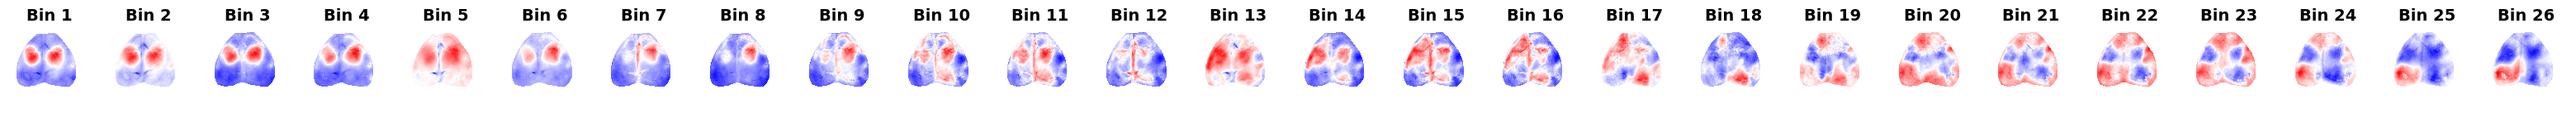

In [176]:
import numpy as np
import matplotlib.pyplot as plt

bin_size_sec = 0.2
frame_rate = 10
bin_size_frames = int(bin_size_sec * frame_rate)  
n_frames = trial_tiff.shape[0]
height, width = trial_tiff.shape[1], trial_tiff.shape[2]


n_bins = n_frames // bin_size_frames


binned_tiff = np.zeros((n_bins, height, width))
binned_tiff = np.where(mask[None, :, :], binned_tiff, np.nan)


for i in range(n_bins):
    start = i * bin_size_frames
    end = start + bin_size_frames
    binned_tiff[i] = np.where(mask, trial_tiff[start:end].mean(axis=0), np.nan)

plt.figure(figsize=(40,5))
for i in range(n_bins):
    plt.subplot(1, n_bins, i+1)
    plt.imshow(binned_tiff[i], cmap='bwr',interpolation='nearest')
    
    plt.axis('off')
    plt.title(f"Bin {i+1}")
plt.show()


In [177]:


def average_trials(trial_list):
    """输入：list of (200, n_frames)，输出：(200, min_frames)"""
    min_frames = min(trial.shape[1] for trial in trial_list)
    trimmed = [trial[:, :min_frames] for trial in trial_list]
    return np.mean(trimmed, axis=0)

averaged_by_type = {}

with h5py.File(filename, 'r') as f:
    data_by_type = {}

    # 遍历所有 trial group
    for group_name in f.keys():
        grp = f[group_name]
        svt = grp['trial_svt'][()]  # shape=(200, n_frames)
        t_type = int(grp['trial_type'][()])
        
        if t_type not in data_by_type:
            data_by_type[t_type] = []
        data_by_type[t_type].append(svt)
    
    # 每个 trial_type 做平均
    for t_type, svts in data_by_type.items():
        avg_svt = average_trials(svts)
        averaged_by_type[t_type] = avg_svt
        print(f"trial_type {t_type}: {len(svts)} trials, "
              f"trimmed to {avg_svt.shape[1]} frames, avg shape={avg_svt.shape}")


trial_type 1: 137 trials, trimmed to 52 frames, avg shape=(200, 52)
trial_type 3: 81 trials, trimmed to 97 frames, avg shape=(200, 97)
trial_type 4: 58 trials, trimmed to 52 frames, avg shape=(200, 52)
trial_type 2: 1 trials, trimmed to 53 frames, avg shape=(200, 53)


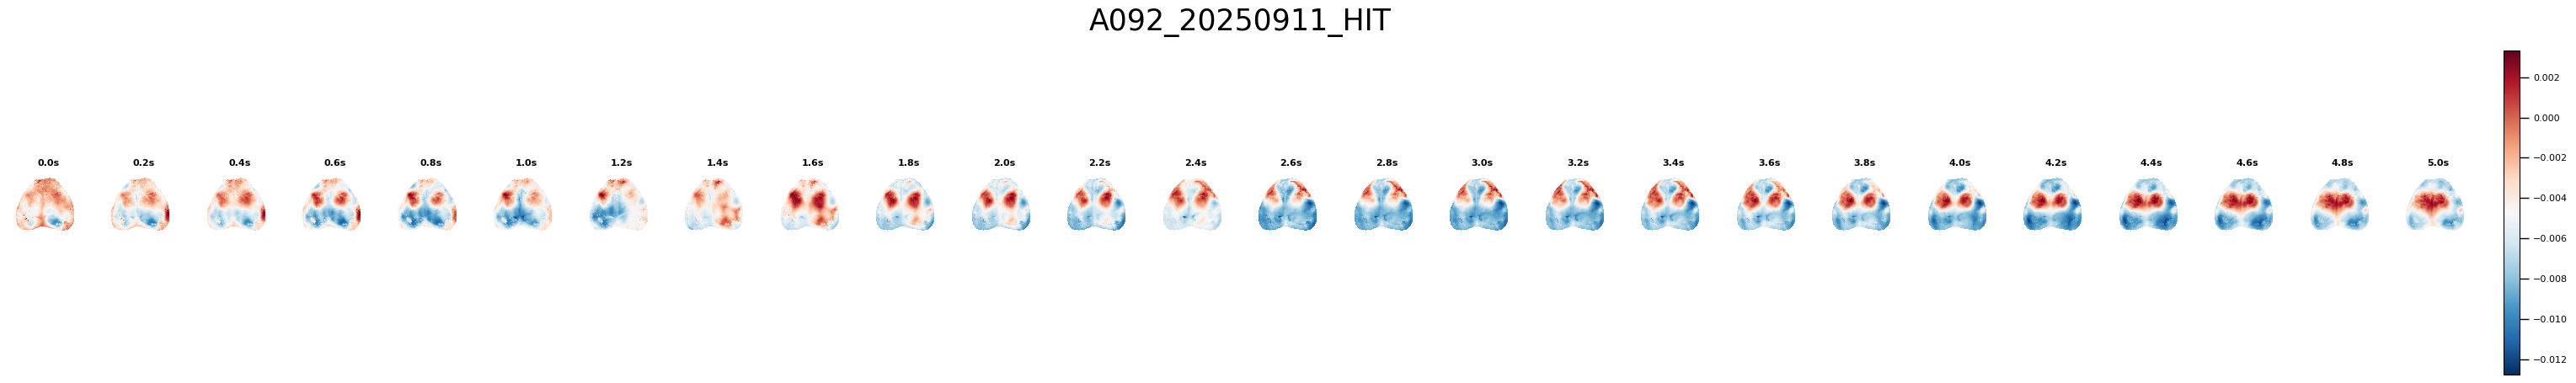

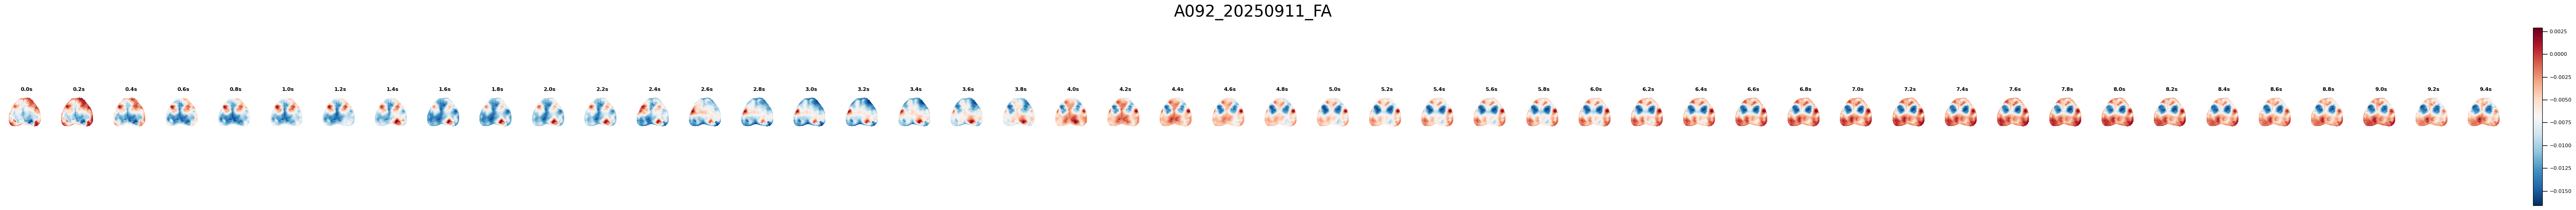

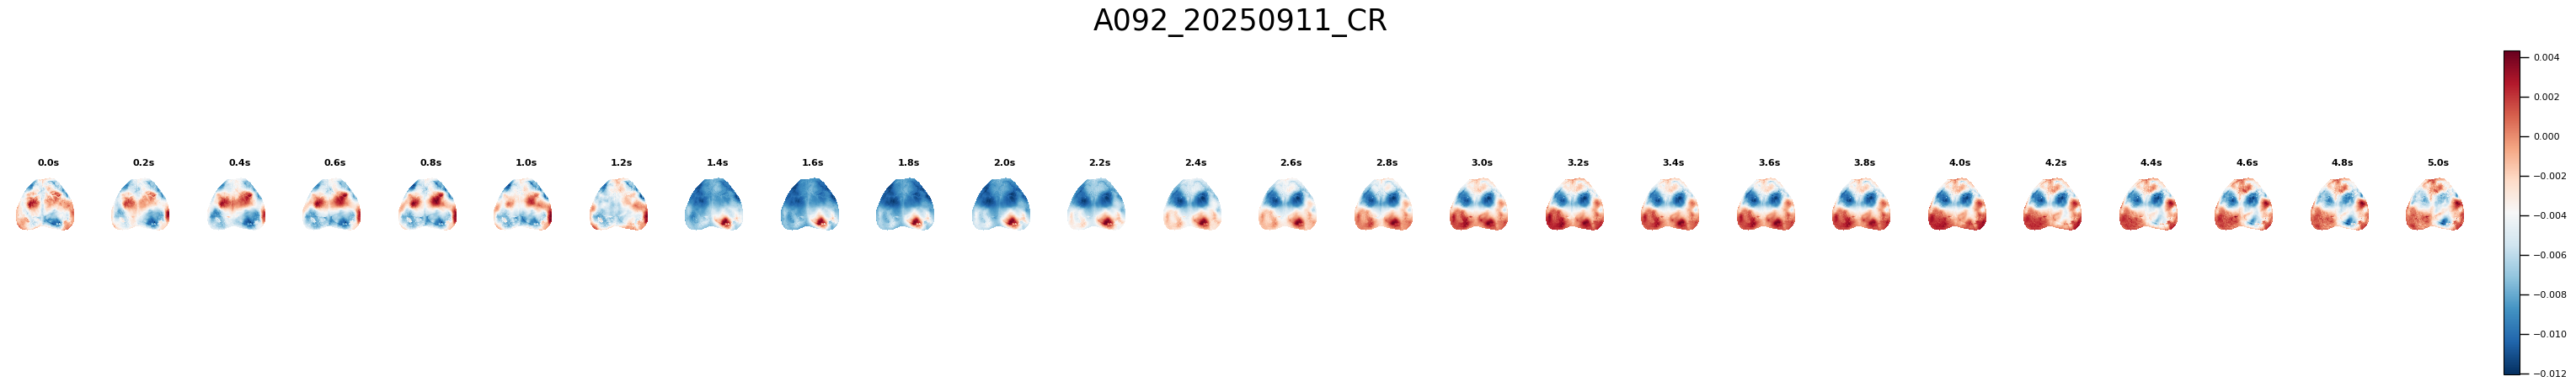

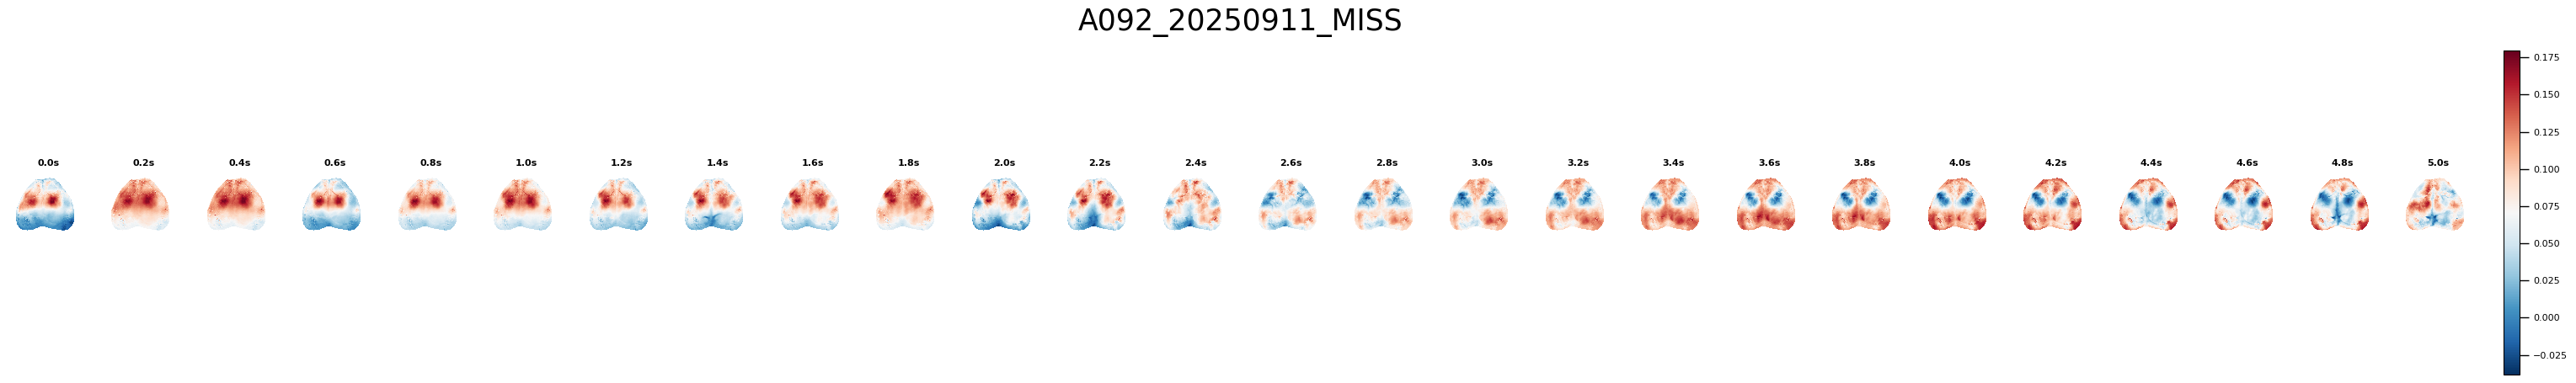

In [178]:
import matplotlib.pyplot as plt
import numpy as np

trial_type_names = {1: 'HIT', 2: 'MISS', 3: 'FA', 4: 'CR'}

bin_size_sec = 0.2
frame_rate = 10
save_dir = (pjoin(processPath,'figure'))
os.makedirs(save_dir, exist_ok=True) 

for t_type, avg_svt in averaged_by_type.items():
    trial_tiff = reconstruct(U, avg_svt)  # shape = (n_frames, height, width)
    n_frames, height, width = trial_tiff.shape
    bin_size_frames = int(bin_size_sec * frame_rate)
    n_bins = n_frames // bin_size_frames

    binned_tiff = np.zeros((n_bins, height, width))
    for i in range(n_bins):
        start = i * bin_size_frames
        end = start + bin_size_frames
        binned_tiff[i] = trial_tiff[start:end].mean(axis=0)
        binned_tiff[i] = np.where(mask, binned_tiff[i], np.nan)

    time_bins = np.arange(n_bins) * bin_size_sec


    plt.figure(figsize=(n_bins*1.5, 5))  

    im_list = []
    for i in range(n_bins):
        ax = plt.subplot(1, n_bins, i+1)
        im = ax.imshow(binned_tiff[i], cmap='RdBu_r', interpolation='nearest')
        ax.axis('off')
        ax.set_title(f"{time_bins[i]:.1f}s", fontsize=8)  
        im_list.append(im)

    plt.colorbar(im_list[0], ax=plt.gcf().get_axes(), orientation='vertical', fraction=0.02, pad=0.01)
    plt.suptitle(f"{mice}_{date}_{trial_type_names[t_type]}", fontsize=25)
    save_path = os.path.join(save_dir, f"{trial_type_names[t_type]}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [144]:
averaged_by_type = {}

with h5py.File(filename, 'r') as f:
    data_by_type = {}

    # 遍历所有 trial group
    for group_name in f.keys():
        grp = f[group_name]
        svt = grp['trial_svt'][()]  # shape=(200, n_frames)
        t_type = int(grp['trial_type'][()])

        if t_type not in data_by_type:
            data_by_type[t_type] = []
        data_by_type[t_type].append(svt)
    
    # 每个 trial_type 做平均
    for t_type, svts in data_by_type.items():
        avg_svt = average_trials(svts)
        # 存 tuple: (avg_svt, trial数)
        averaged_by_type[t_type] = (avg_svt, len(svts))
        print(f"trial_type {t_type}: {len(svts)} trials, "
              f"trimmed to {avg_svt.shape[1]} frames, avg shape={avg_svt.shape}")


trial_type 3: 43 trials, trimmed to 52 frames, avg shape=(200, 52)
trial_type 4: 107 trials, trimmed to 52 frames, avg shape=(200, 52)
trial_type 1: 33 trials, trimmed to 52 frames, avg shape=(200, 52)
trial_type 2: 117 trials, trimmed to 52 frames, avg shape=(200, 52)


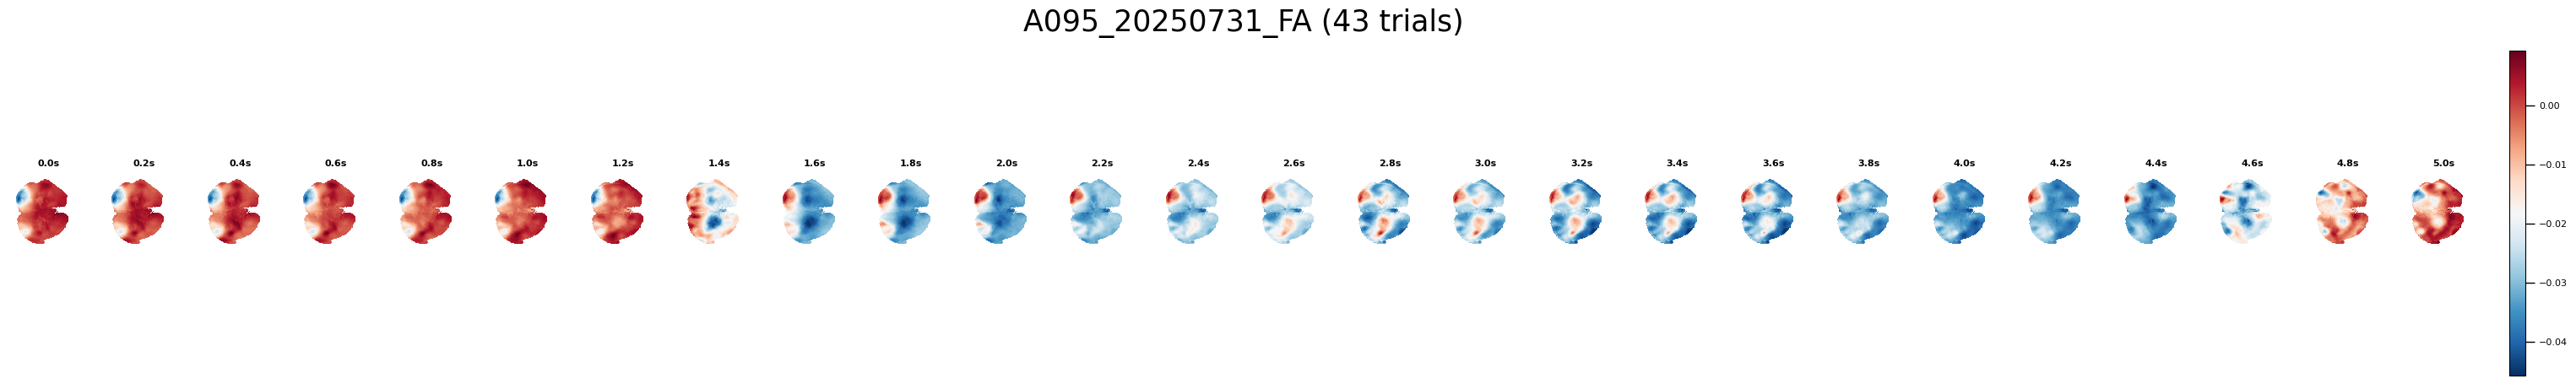

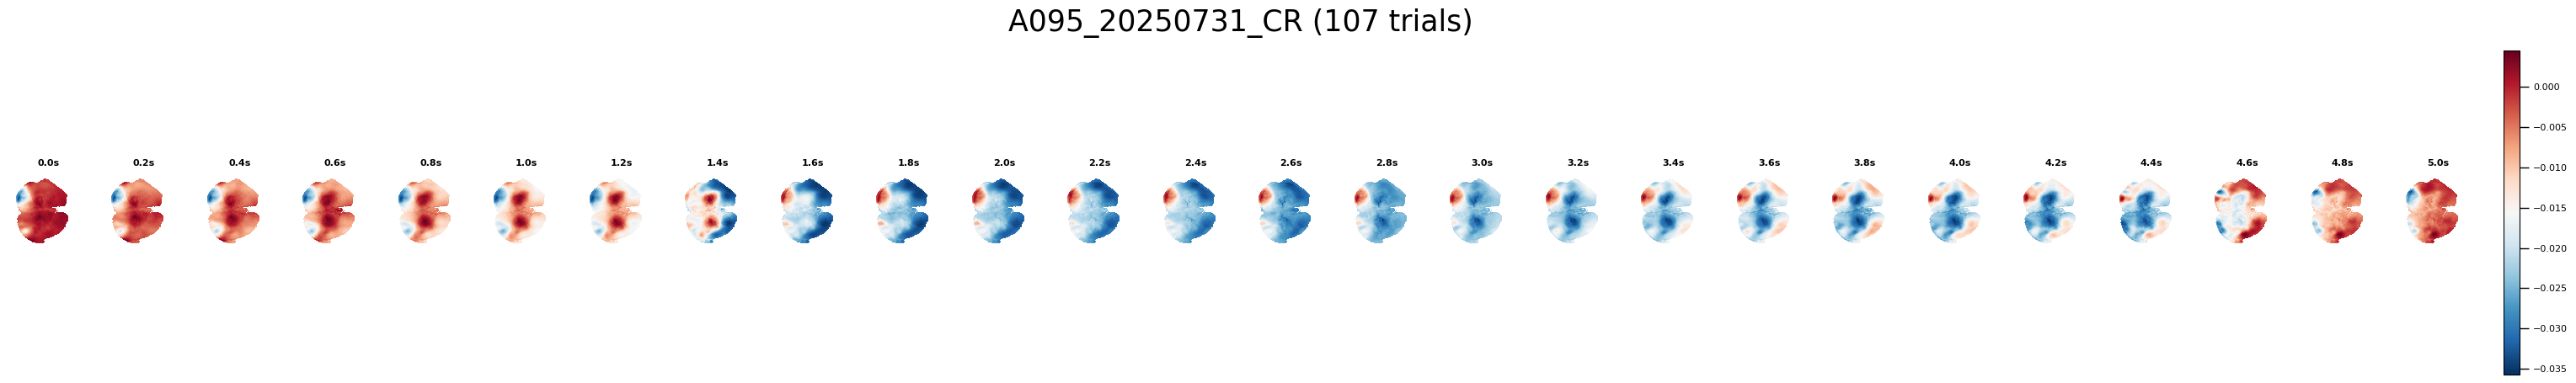

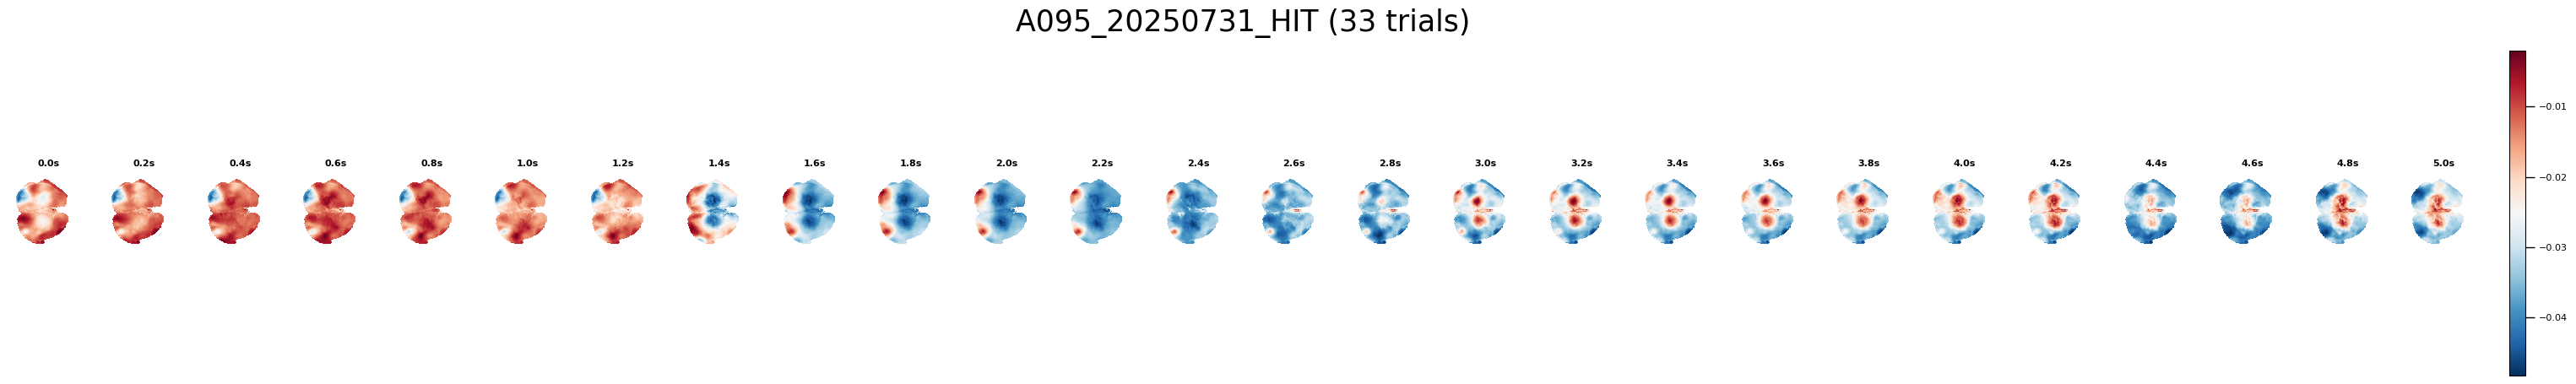

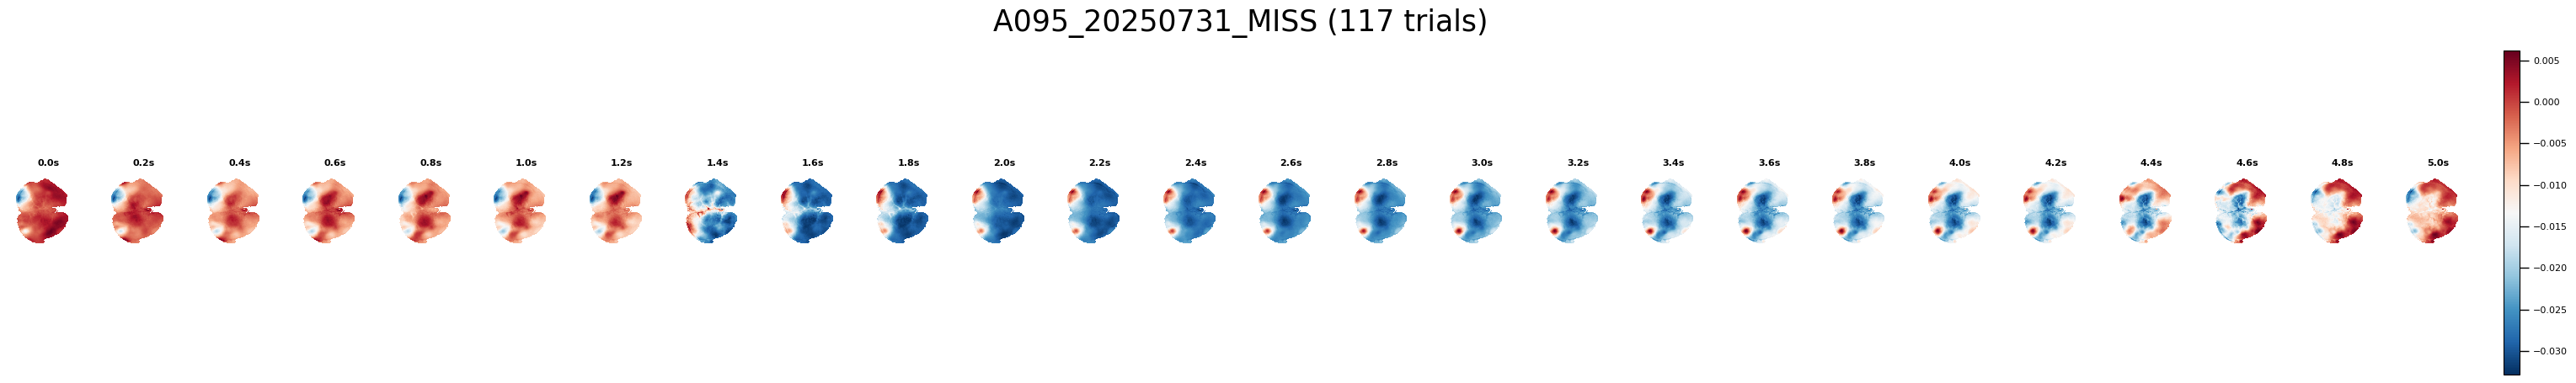

In [145]:
for t_type, (avg_svt, n_trials) in averaged_by_type.items():
    trial_tiff = reconstruct(U, avg_svt)  # shape = (n_frames, height, width)
    n_frames, height, width = trial_tiff.shape
    bin_size_frames = int(bin_size_sec * frame_rate)
    n_bins = n_frames // bin_size_frames

    binned_tiff = np.zeros((n_bins, height, width))
    for i in range(n_bins):
        start = i * bin_size_frames
        end = start + bin_size_frames
        binned_tiff[i] = trial_tiff[start:end].mean(axis=0)
        binned_tiff[i] = np.where(mask, binned_tiff[i], np.nan)

    time_bins = np.arange(n_bins) * bin_size_sec

    plt.figure(figsize=(n_bins*1.5, 5))  

    im_list = []
    for i in range(n_bins):
        ax = plt.subplot(1, n_bins, i+1)
        im = ax.imshow(binned_tiff[i], cmap='RdBu_r', interpolation='nearest')
        ax.axis('off')
        ax.set_title(f"{time_bins[i]:.1f}s", fontsize=8)  
        im_list.append(im)

    plt.colorbar(im_list[0], ax=plt.gcf().get_axes(), orientation='vertical', fraction=0.02, pad=0.01)
    plt.suptitle(f"{mice}_{date}_{trial_type_names[t_type]} ({n_trials} trials)", fontsize=25)
    save_path = os.path.join(save_dir, f"{trial_type_names[t_type]}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


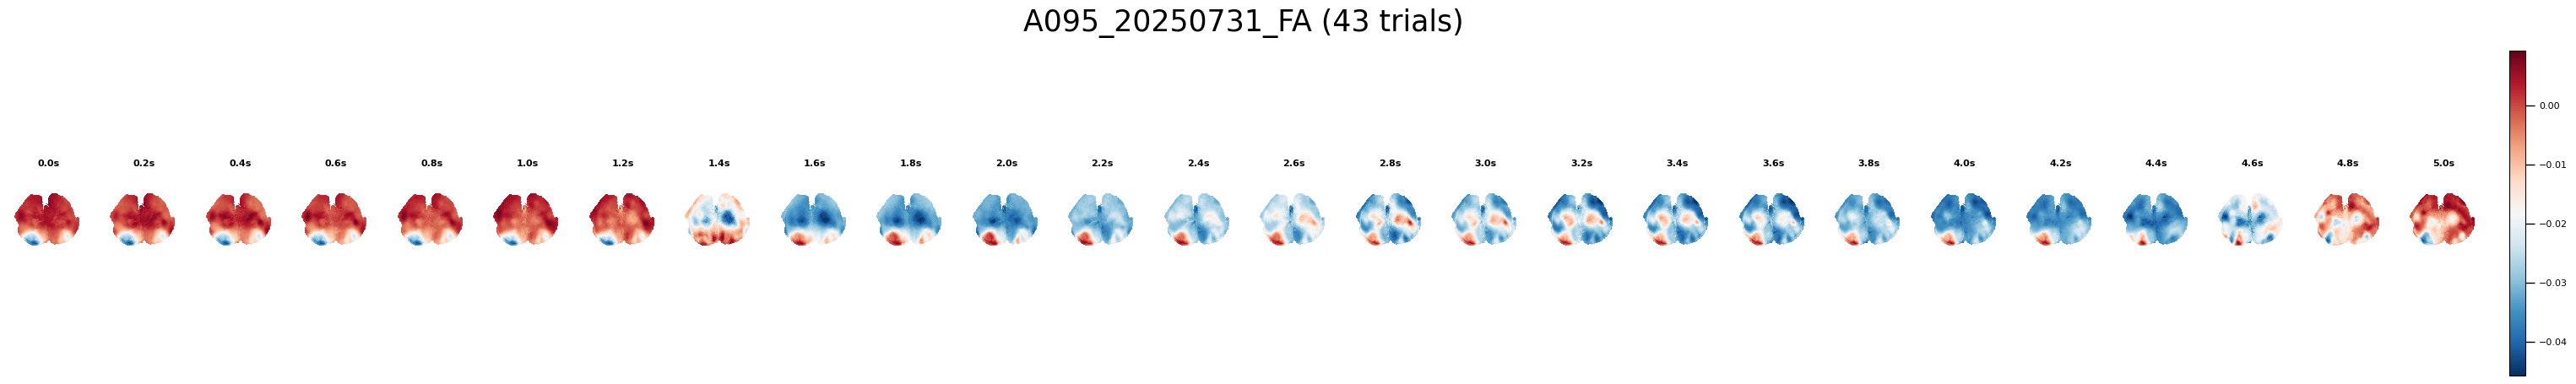

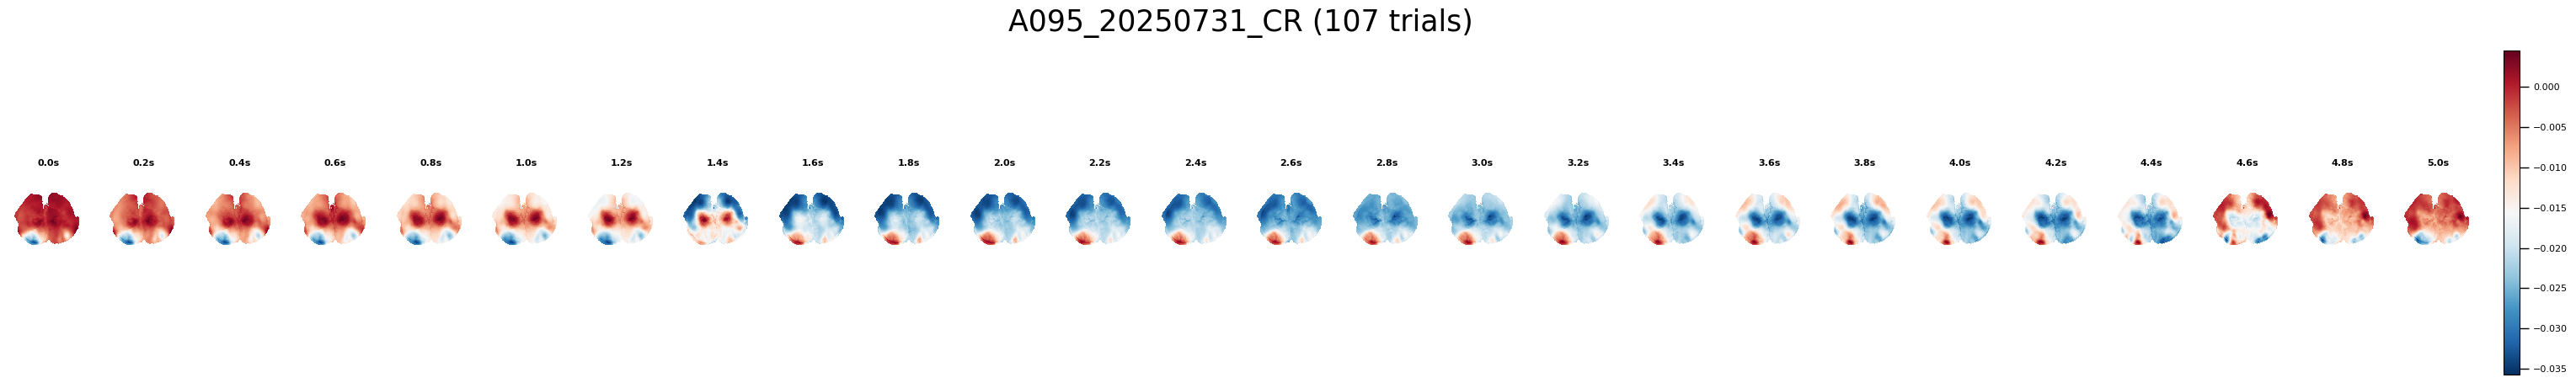

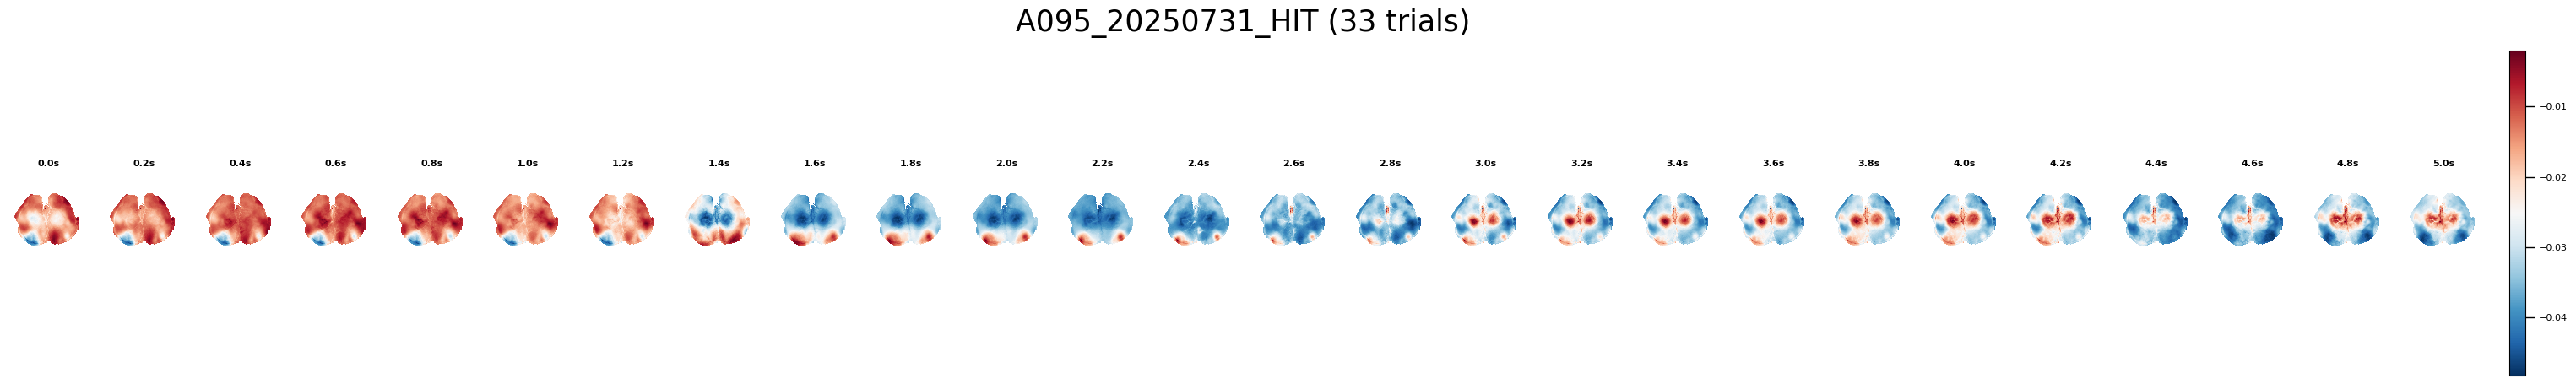

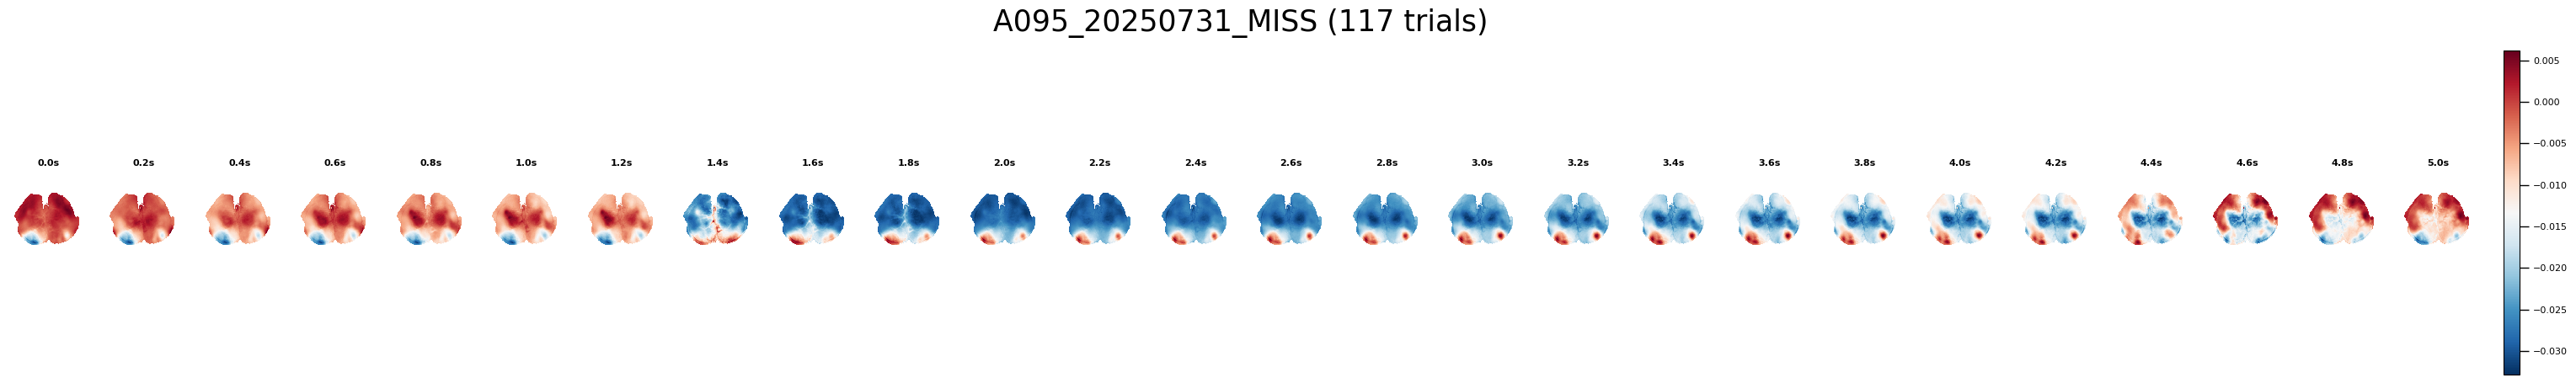

In [146]:
for t_type, (avg_svt, n_trials) in averaged_by_type.items():
    trial_tiff = reconstruct(U, avg_svt)  # shape = (n_frames, height, width)
    n_frames, height, width = trial_tiff.shape
    bin_size_frames = int(bin_size_sec * frame_rate)
    n_bins = n_frames // bin_size_frames

    binned_tiff = np.zeros((n_bins, height, width))
    for i in range(n_bins):
        start = i * bin_size_frames
        end = start + bin_size_frames
        binned_tiff[i] = trial_tiff[start:end].mean(axis=0)
        binned_tiff[i] = np.where(mask, binned_tiff[i], np.nan)

    time_bins = np.arange(n_bins) * bin_size_sec

    plt.figure(figsize=(n_bins*1.5, 5))  

    im_list = []
    for i in range(n_bins):
        ax = plt.subplot(1, n_bins, i+1)
        # 在显示前逆时针旋转90度
        im = ax.imshow(np.rot90(binned_tiff[i]), cmap='RdBu_r', interpolation='nearest')
        ax.axis('off')
        ax.set_title(f"{time_bins[i]:.1f}s", fontsize=8)  
        im_list.append(im)

    plt.colorbar(im_list[0], ax=plt.gcf().get_axes(), orientation='vertical', fraction=0.02, pad=0.01)
    plt.suptitle(f"{mice}_{date}_{trial_type_names[t_type]} ({n_trials} trials)", fontsize=25)
    save_path = os.path.join(save_dir, f"{trial_type_names[t_type]}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
